# Low pass filtering

As specified on the datasheet and register map, the MPU6050 has a built-in digital low pass filter. It's helpful because it provides some smoothing, noise reduction and anti-aliasing at zero computational cost on the microcontroller. On the other hand, it introduces a delay/phase shift in the signal, getting worse with lower cutoff frequencies. Unfortunately, the exact characteristics of the filter are not specified. Instead, only the cutoff frequency can be configured by setting the DLPF_CFG bits in the CONFIG register (26). Available frequencies are: 

| DLPF_CFG | Accel Bandwidth (Hz) | Delay (ms) | Gyro Bandwidth (Hz) | Delay (ms) | Fs (kHz) |
|----------|---------------------|------------|----------------------|------------|-----|
| 0 | 256 | 0.98 | 260 | 0.98 | 8 |
| 1 | 188 | 1.9  | 184 | 2.0  | 1 |
| 2 | 98  | 2.8  | 94  | 3.0  | 1 |
| **3** | **42**  | **4.8**  | **44**  | **4.9**  | **1** |
| 4 | 20  | 8.3  | 21  | 8.5  | 1 |
| 5 | 10  | 13.4 | 10  | 13.8 | 1 |
| 6 | 5   | 18.6 | 5   | 19.0 | 1 |
| 7 | RESERVED | RESERVED | RESERVED | RESERVED | 8 |

Other filter characteristics like the order, the type, or the presence of passband ripple or ringing are not specified. It's assumed that it's a digital low order IIR (infinite-impulse response) filter. I think this because the sensor was/is designed to be low power and low cost, and otherwise Invensense would have leveraged the filter characteristics as a selling point.

Based on a brief research and common sense, most common human movements fall comfortably below 10-20Hz, but since device will be used for high speed/power movements and there may be impacts, vibration or resonance, a margin of safety is needed. Additionally, according to the sampling theorem, the sampling frequency should be at least twice the highest frequency of interest to avoid aliasing. Based on this, 42/44Hz seems like a good first choice, trying to match it with a sampling frequency of at least 100Hz ideally. 

To avoid overengineering, initially I thought of just using this built-in filter, but additional filtering is needed since I have seen downstream that velocity is very sensitive to noise. A fast software low pass filter like the moving average filter (which is a FIR, finite impulse response) will be tested with different kernel lengths to find a good compromise between noise reduction, responsiveness, and signal sharpness. Here, convolution with a rectangular kernel will be used, but on the device it can be implemented as a fixed-size sliding window, which is more efficient ($O(n)$ instead of $O(k \cdot n)$, where $k$ is the length of the kernel and $n$ is the signal length). This filter has linear phase (i.e. symmetric impulse response with $k$ being odd that produces a constant delay) and it's a good choice for white noise reduction.

Notice that the alternative on the time domain, a single pole IIR filter, while it requires a similar programming effort than the moving average (minimal), it has a non-linear phase response, which can distort the signal by introducing non-constant delays, and to make it zero-phase two passes of filtering are needed (one forwards and one backwards), which is not possible for the decided streaming, real-time architecture. Because of this reason, it will not be used.

Also notice that frequency domain filtering, while it can provide a decent signal smoothing, creates a Gibbs-like effect on the signal, which is unacceptable for the application.  

Resources:
* https://valdperformance.com/news/sampling-frequency-how-much-is-enough
* [The scientist and engineer's guide to digital signal processing, Steven W. Smith - Chapters 3, 15, 19, 21](../../docs/misc/The%20Scientist%20and%20Engineers%20Guide%20to%20Digital%20signal%20processing%20-%20Steven%20W.%20Smith.pdf)
* https://www.youtube.com/watch?v=t3fCbQCSeQs
* [MPU6050 datasheet](../../docs/misc/MPU6050%20datasheet.pdf)
* [MPU6050 register map](../../docs/misc/MPU6050%20registers.pdf)



## Setup

In [24]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

sixFaceStationaryCaptures = [
    "../1-calibration/output/pos-x-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-z-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-z-up-calib-affine-sixf-tilted-a-online-w.csv",
]
tiltedStationaryCaptures = [
    "../1-calibration/output/pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
]

simpleRotationsCaptures = [
    "../1-calibration/output/rot-x-hw-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/rot-y-hw-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/rot-z-hw-calib-affine-sixf-tilted-a-online-w.csv",
]

realExerciseCaptures = [
    "../1-calibration/output/dips-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/dips-2-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/dips-3-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-2-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-3-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w.csv",
]

reader = IMUSampleReader()
writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(
    [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]
)


def plotFilteredSignal(capture, lowerP, upperP, kernelLengths):
    colors = [
        "tab:red",
        "tab:green",
        "tab:blue",
        "tab:cyan",
        "tab:orange",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
        "tab:olive",
        "tab:cyan",
    ]
    if len(kernelLengths) > len(colors) - 1:
        raise ValueError(
            f"Too many kernel lengths ({len(kernelLengths)}) for available colors ({len(colors) - 1})"
        )

    fig, axes = plt.subplots(2, 1, figsize=(20, 6))

    seq, a, w = reader.readRaw(capture)
    aNorm = np.linalg.norm(a, axis=1)
    wNorm = np.linalg.norm(w, axis=1)

    axes[0].set_title("Accelerometer")
    axes[0].set_xlabel("Sequence number")
    axes[0].set_ylabel("Norm (m/s²)")
    axes[0].grid()

    axes[1].set_title("Gyroscope")
    axes[1].set_xlabel("Sequence number")
    axes[1].set_ylabel("Norm (deg/s)")
    axes[1].grid()

    axes[0].plot(seq, aNorm, label="Original", color=colors[0])
    axes[1].plot(seq, wNorm, label="Original", color=colors[0])

    # Upper and lower vertical limits
    axes[0].set_ylim(np.percentile(aNorm, lowerP), np.percentile(aNorm, upperP))
    axes[1].set_ylim(np.percentile(wNorm, lowerP), np.percentile(wNorm, upperP))

    # Stationary bands
    aNormLow = stationaryChecker.accelMean - stationaryChecker.accelTol
    aNormHigh = stationaryChecker.accelMean + stationaryChecker.accelTol
    axes[0].axhspan(
        aNormLow, aNormHigh, color="tab:grey", alpha=0.25, label="Stationary band"
    )

    wNormLow = stationaryChecker.gyroMean - stationaryChecker.gyroTol
    wNormHigh = stationaryChecker.gyroMean + stationaryChecker.gyroTol
    axes[1].axhspan(wNormLow, wNormHigh, color="tab:grey", alpha=0.25)

    for j, kLen in enumerate(kernelLengths):
        kernel = np.ones(kLen) / kLen
        aFiltered = np.array(
            [
                sp.signal.convolve(a[:, 0], kernel, mode="same"),
                sp.signal.convolve(a[:, 1], kernel, mode="same"),
                sp.signal.convolve(a[:, 2], kernel, mode="same"),
            ]
        ).T

        wFiltered = np.array(
            [
                sp.signal.convolve(w[:, 0], kernel, mode="same"),
                sp.signal.convolve(w[:, 1], kernel, mode="same"),
                sp.signal.convolve(w[:, 2], kernel, mode="same"),
            ]
        ).T

        aNorm = np.linalg.norm(aFiltered, axis=1)
        wNorm = np.linalg.norm(wFiltered, axis=1)

        axes[0].plot(
            seq,
            aNorm,
            label=f"k={kLen}",
            color=colors[1 + j],
        )
        axes[1].plot(
            seq,
            wNorm,
            label=f"k={kLen}",
            color=colors[1 + j],
        )
        axes[0].legend()
        axes[1].legend()

    fig.tight_layout()
    plt.show()

Acceleration norms:
	Mean = 9.803800
	Stdev = 0.080243
	Interval = [9.563072, 10.044527]
Gyroscope norms:
	Mean = 0.171970
	Stdev = 1.717855
	Interval = [-4.981595, 5.325534]


## Graphical inspection

The norm instead of each axis is plotted to simplify the inspection

Bigger kernels may make the signal move away from an imagined noise-free, least-squares fitted signal in some isolated cases. Some amplitude is lost. Sharpness is not compromised too much. A kernel of more than about 15 samples is unnecessary. 

Being careful of the scale of the graphs, the accelerometer and gyroscope may have different noise reduction needs. However, using different kernel sizes for each sensor may be a bad idea, since that will introduce two different delays in the signals and alter orientation downstream. So, either a compromise is needed.

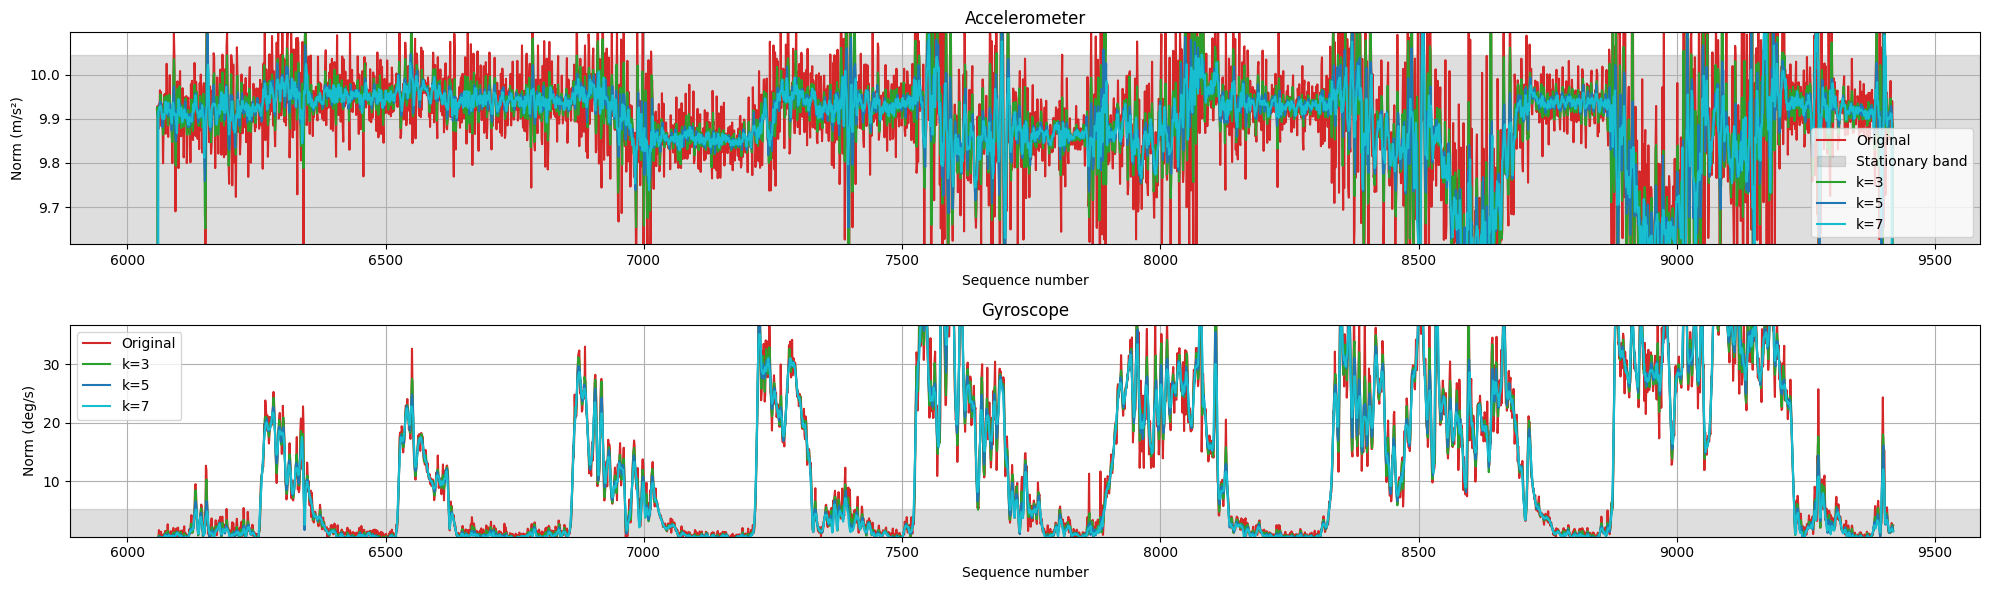

In [25]:
# CHOSEN_CAPTURE = sixFaceStationaryCaptures[0]
# CHOSEN_CAPTURE = tiltedStationaryCaptures[0]
CHOSEN_CAPTURE = simpleRotationsCaptures[0]
# CHOSEN_CAPTURE = realExerciseCaptures[6]
plotFilteredSignal(CHOSEN_CAPTURE, 5, 95, [3, 5, 7])

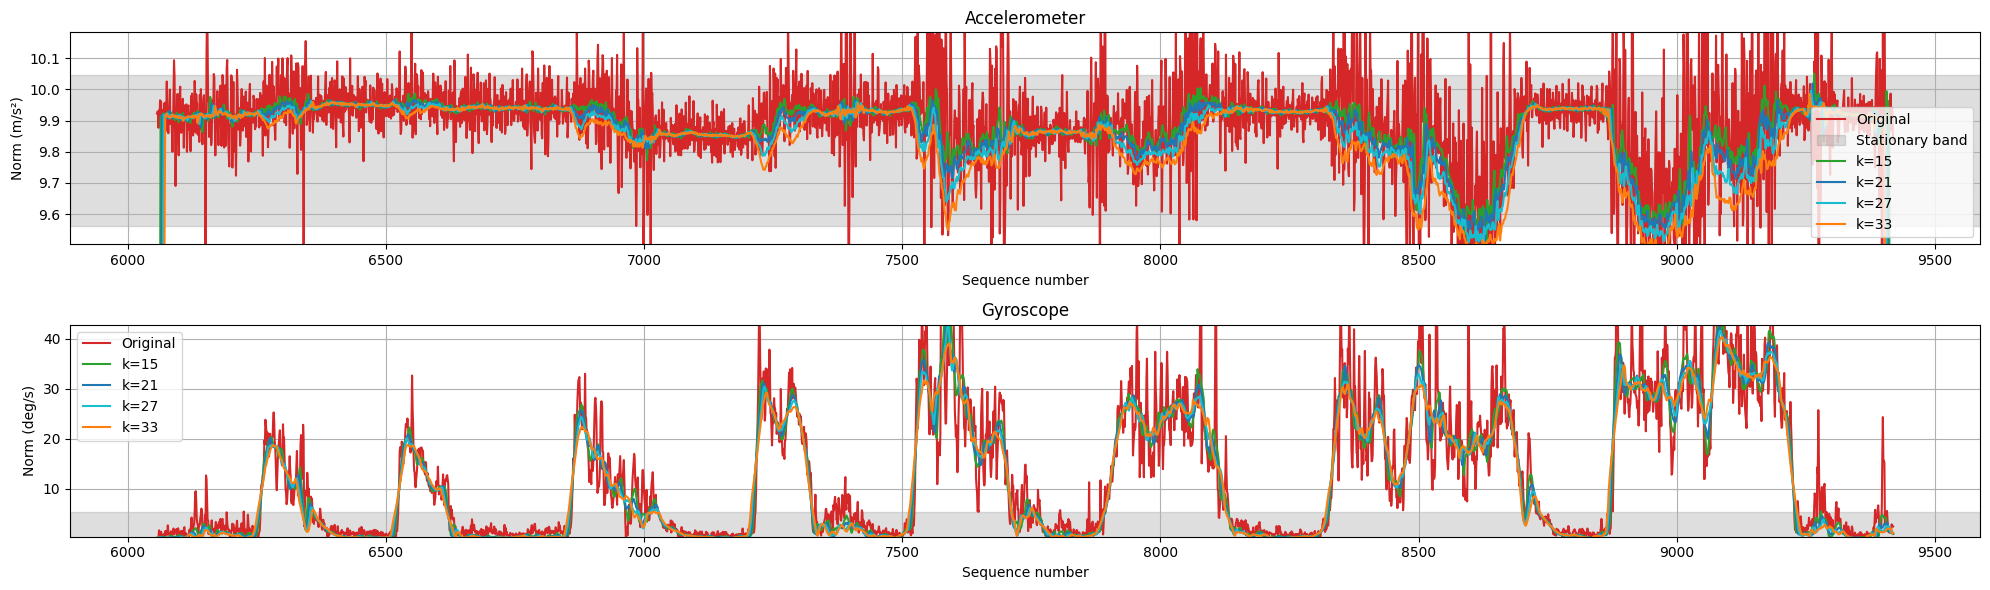

In [26]:
plotFilteredSignal(CHOSEN_CAPTURE, 2.5, 97.5, [15, 21, 27, 33])

# Numerical inspection

The standard deviation of stationary intervals is a proxy for noise. A relatively low value is preferred.